# Decoding

In [1]:
import pandas as pd
import numpy as np
import os
import json
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
plt.style.use('seaborn-v0_8-dark')


In [2]:
from src.config import OUT_PATH, EVENT_ID, FREQ_BAND, col_pc, color_event, event_idx
from utils import ExcludSubj, CompareModelsGGPlot, cleandfdecodingTS
from matplotlib.lines import Line2D

tfr_path = OUT_PATH + '/Data_longWOBS'
event= list(EVENT_ID.keys())[:2]
subj_included = [file.replace('_TFRtrials.p', '') for file in os.listdir(tfr_path) if file[-len('_TFRtrials.p'):] == '_TFRtrials.p']
subj_included = ExcludSubj(subj_included, data_path=tfr_path)

path = tfr_path + f'/{subj_included[0]}_info.json'
with open(path) as json_data:
    d = json.load(json_data)
    time_epoch = d['time_epoch']
    time_tfr=d['time_tfr']

## RAW

In [3]:
data= pd.read_csv('/Volumes/barbara/Desktop/MIB_iEEG/outs/Decoding_shuffled_trials/broadband/broadband_mean_pc123_duplicat_weights_CLF.csv').drop(columns = 'Unnamed: 0').T
#data= pd.read_csv(OUT_PATH + '/Decoding_shuffled_trials/broadband/broadband_Raw_duplicat_weights_CLF.csv').drop(columns = 'Unnamed: 0').T
time = time_epoch
from utils import GetInfo
_, _, _, _, regions = GetInfo(subj_included, data_path=tfr_path)

data = abs(data)
#data['ROIs'] = regions

df_grp = data #.groupby('ROIs').mean()

fig, ax = plt.subplots(2, 1, figsize = (20, 10) , sharex=True)
sns.heatmap(df_grp, cmap='Greys', ax=ax[0], cbar=False)
step = 100
ax[0].set_xticks(np.arange(0, len(time), step))
ax[0].set_xticklabels([np.round(t, 1) for t in time[::step]], rotation=45, ha='right')
ax[0].set_yticklabels(['PC1', 'PC2', 'PC3']) #df_grp.index.values)

#data2 = pd.read_csv(OUT_PATH + '/Decoding_shuffled_trials/broadband/broadband_Raw_duplicat_TpointSummary.csv').drop(columns = 'Unnamed: 0').T
data2 = pd.read_csv(OUT_PATH + '/Decoding_shuffled_trials/broadband/broadband_mean_pc123_duplicat_TpointSummary.csv').drop(columns = 'Unnamed: 0').T
acc = data2.loc['acc_mean', 0].replace('[', '').replace(']', '').replace("\n", "").replace("'", "").replace(')', '').replace('   ', ' ').replace('  ', ' ').split(' ')
acc= np.array([float(t) for t in acc if t!= ''])

acc_std = data2.loc['acc_std', 0].replace('[', '').replace(']', '').replace("\n", "").replace("'", "").replace(')', '').replace('   ', ' ').replace('  ', ' ').split(' ')
acc_std= np.array([float(t) for t in acc_std if t!= ''])
acc_std = acc_std/np.sqrt(100)
ax[1].plot(acc, c='k', label='Mean Accuracy')
ax[1].fill_between(np.arange(len(time)),  acc - acc_std, acc+acc_std, alpha = 0.3, color='grey', label='Standard Error')
ax[1].grid()
ax[1].set_ylabel('Accuracy')
ax[1].set_xlabel('Time (s)')

ax[1].hlines(y=0.5,xmin=0,xmax=len(time),colors='red',linestyles='dashed',linewidth=0.5, label = 'Chance level')

# transform = pd.read_csv(OUT_PATH +  f'/grpPCA/supsubj_mean/grp_mean_Xtrans_PCA5.csv')
# time_serie_df = transform.query('freq == "high_gamma" and compo == "compo1"')

# for col in ['Unnamed: 0', 'freq' , 'compo', 'subj', 'expl_var'] :
#     if col in time_serie_df.columns :
#         time_serie_df = time_serie_df.drop(columns = col)
# time_serie = time_serie_df.values
# ax[2].plot(time_serie.T)
ax[1].legend(ncol=4)

FileNotFoundError: [Errno 2] No such file or directory: '/Volumes/barbara/Desktop/MIB_iEEG/outs/Decoding_shuffled_trials/broadband/broadband_mean_pc123_duplicat_weights_CLF.csv'

## FINAL Decoding TS

In [60]:
band = 'high_gamma'
method_pca = 'concat'
data_aug_method = 'duplicat'
PC_use = 2
model_name = 'RandomForest'
time = time_tfr #time_epoch #time_tfr[:time_tfr.index(np.array(time_tfr)[np.array(time_tfr) > -0.5][0])]

df_final = pd.read_csv(OUT_PATH + f'/Decoding_shuffled_trials/{band}/fullmodel/{method_pca}_{data_aug_method}_{PC_use}_{model_name}full.csv') #_crp18_197_

result = cleandfdecodingTS(df_final, len(time))

In [61]:
print('Class Balance :', np.unique(result['y_pred'], return_counts=True)[1][0]/2, np.unique(result['y_pred'], return_counts=True)[1][1]/2)
print('General Accuracy:', result['acc'])
print('General Accuracy Permuted:', result['acc_sh'])


Class Balance : 56.0 44.0
General Accuracy: 0.74
General Accuracy Permuted: 0.49870000000000003


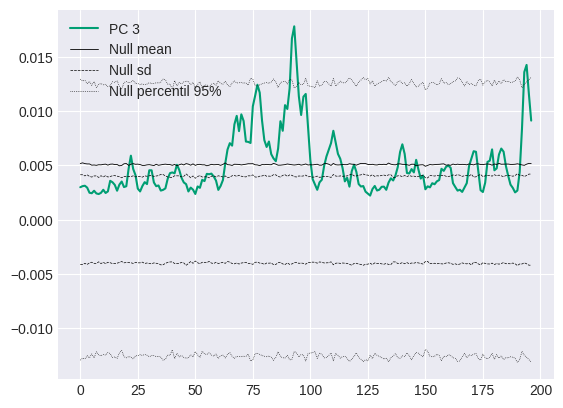

In [62]:
plt.plot(result['weight_mean'], c=col_pc[PC_use], label=f'PC {PC_use + 1}')
plt.plot(np.percentile(result['weight_sh'], 95, axis=0), c='black', linewidth=0.5, ls=':')
plt.plot(result['weight_sh_mean'],  c='black', linewidth=0.6, label='Null mean')
plt.plot(result['weight_sh_std'], c= 'black', ls='--', linewidth=0.5)
plt.plot(- result['weight_sh_std'], c= 'black', ls='--', linewidth=0.5, label='Null sd')
plt.plot(- np.percentile(result['weight_sh'], 95, axis=0), c='black', linewidth=0.5, ls=':', label='Null percentil 95%')
plt.legend()
plt.grid()
plt.show()


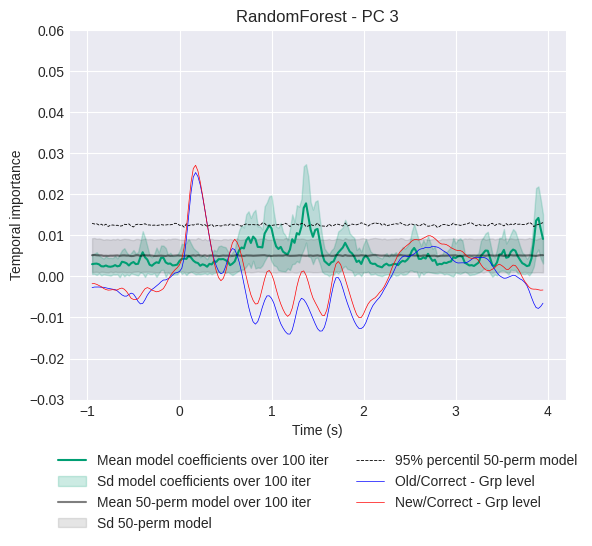

In [63]:
# IF WEIGHTS
weight_mean= result['weight_mean']
weight_std= result['weight_std']
weight_sh_mean= result['weight_sh_mean']
weight_sh_std= result['weight_sh_std']

fig, ax = plt.subplots()
ax.plot(time, weight_mean, color=col_pc[PC_use], label = 'Mean model coefficients over 100 iter')
ax.fill_between(time, weight_mean - weight_std,weight_mean+weight_std, alpha = 0.2, color = col_pc[PC_use], label = 'Sd model coefficients over 100 iter')
ax.plot(time, weight_sh_mean, color='black',alpha=0.5,  label = f'Mean {int(df_final.loc[0, "iter_perm"])}-perm model over {int(df_final.loc[0, "iter"])} iter')
ax.fill_between(time, abs(weight_sh_mean) - weight_sh_std, abs(weight_sh_mean)+weight_sh_std, alpha = 0.1, color = 'black', label = f'Sd {int(df_final.loc[0, "iter_perm"])}-perm model')
#ax.plot(time, - np.percentile(result['weight_sh'], 95, axis=0), alpha = 1,ls='--', linewidth=0.6, color = 'black')
ax.plot(time, np.percentile(result['weight_sh'], 95, axis=0), alpha = 1, ls='--', linewidth=0.6, color = 'black', label = f'95% percentil {int(df_final.loc[0, "iter_perm"])}-perm model')


transform = pd.read_csv(OUT_PATH +  f'/grpPCA/supsubj_{method_pca}/grp_{method_pca}_Xtrans_PCA5.csv')
compo_lab = 'compo' + str(PC_use+1)
time_serie_df = transform.query('freq == @band and compo == @compo_lab')

for col in ['Unnamed: 0', 'freq' , 'compo', 'subj', 'expl_var'] :
    if col in time_serie_df.columns :
        time_serie_df = time_serie_df.drop(columns = col)
time_serie = time_serie_df.values

#[time_tfr.index(np.array(time_tfr)[np.array(time_tfr) > -0.5][0]):]
ax.plot(time, 0.004* time_serie[0, :int(time_serie.shape[1]/2)]*2, label = 'Old/Correct - Grp level', c = 'b', alpha = 1, linewidth=0.5)
ax.plot(time, 0.004*time_serie[0, int(time_serie.shape[1]/2):]*2, label = 'New/Correct - Grp level', c = 'r', alpha = 1, linewidth=0.5)

ax.legend(bbox_to_anchor = (0.5, -0.25),loc ='center', ncol  =2)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Temporal importance')
ax.set_ylim(-0.03, 0.06)
ax.set_title(f"{model_name.replace('_', ' ')} - PC {PC_use+1}")
ax.grid()

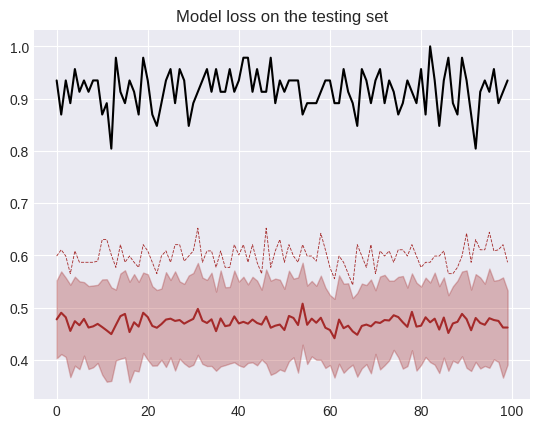

In [54]:
# for the sh take the mean over the 100
entropy_sh = result['entropy_sh']
entropy = result['entropy']

plt.plot(np.arange(100), entropy, label = 'entropy model', c='black')
plt.plot(entropy_sh.mean(1), label = 'entropy perm', c='brown')
plt.plot(np.percentile(entropy_sh, q=95,axis=1),  c='brown', ls='--', linewidth = 0.6)
plt.fill_between(np.arange(100), entropy_sh.mean(1)-entropy_sh.std(1), entropy_sh.mean(1)+entropy_sh.std(1), color = 'brown', alpha = 0.3)
plt.title('Model loss on the testing set')
plt.grid()

In [33]:
np.mean(entropy)

np.float64(0.6906521739130436)

In [35]:
# Accuracy per trials 
from sklearn.metrics import accuracy_score, f1_score
acc_p = []
acc_p_sh_std =[]
acc_p_sh_mean=[]
for i in range(100) :
    acc_p.append(accuracy_score(result['y_pred'][i*2:(i+1)*2], [1, 2]))
    acc_p_sh_ = []
    for j in range(50):
        acc_p_sh_.append(accuracy_score(result['y_pred_sh'][i*2:(i+1)*2, j ], [1, 2]))
    acc_p_sh_mean.append(np.mean(acc_p_sh_))
    acc_p_sh_std.append(np.std(acc_p_sh_))
acc_p_sh_mean = np.array(acc_p_sh_mean)
acc_p_sh_std = np.array(acc_p_sh_std)

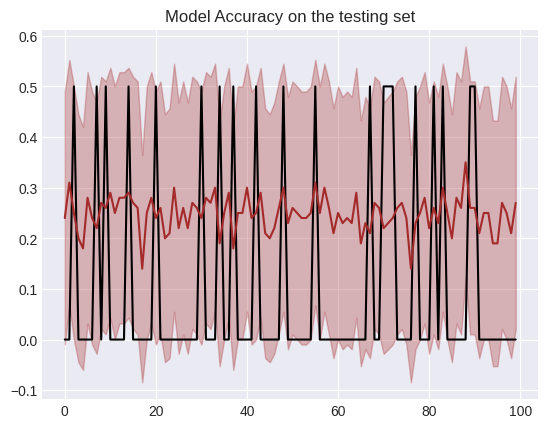

In [36]:

plt.plot(np.arange(100), acc_p, label = 'Accuracy model', c='black')
plt.plot(acc_p_sh_mean, label = 'Accuracy perm mean', c='brown')
plt.fill_between(np.arange(100), acc_p_sh_mean-acc_p_sh_std, acc_p_sh_mean+acc_p_sh_std, color = 'brown', alpha = 0.3)
plt.title('Model Accuracy on the testing set')
plt.grid()


In [12]:

acc_p = []
acc_p_sh_std =[]
acc_p_sh_mean=[]
for i in range(100) :
    acc_p.append(f1_score(result['y_pred'][i*2:(i+1)*2], [1, 2]))
    acc_p_sh_ = []
    for j in range(50):
        acc_p_sh_.append(f1_score(result['y_pred_sh'][i*2:(i+1)*2, j ], [1, 2]))
    acc_p_sh_mean.append(np.mean(acc_p_sh_))
    acc_p_sh_std.append(np.std(acc_p_sh_))
acc_p_sh_mean = np.array(acc_p_sh_mean)
acc_p_sh_std = np.array(acc_p_sh_std)

ValueError: Target is multiclass but average='binary'. Please choose another average setting, one of [None, 'micro', 'macro', 'weighted'].

Text(13.08333333333333, 0.5, 'True')

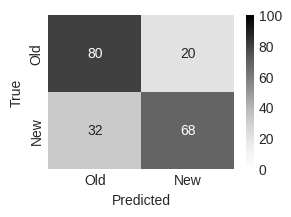

In [37]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

fig, ax = plt.subplots(figsize =(3, 2))
sns.heatmap(confusion_matrix(result['y_test'], result['y_pred']), annot=True, cmap='Greys', ax=ax, vmin=0, vmax=100)
ax.set_xticklabels(['Old', 'New'])
ax.set_xlabel('Predicted')
ax.set_yticklabels(['Old', 'New'])
ax.set_ylabel('True')

#### legend

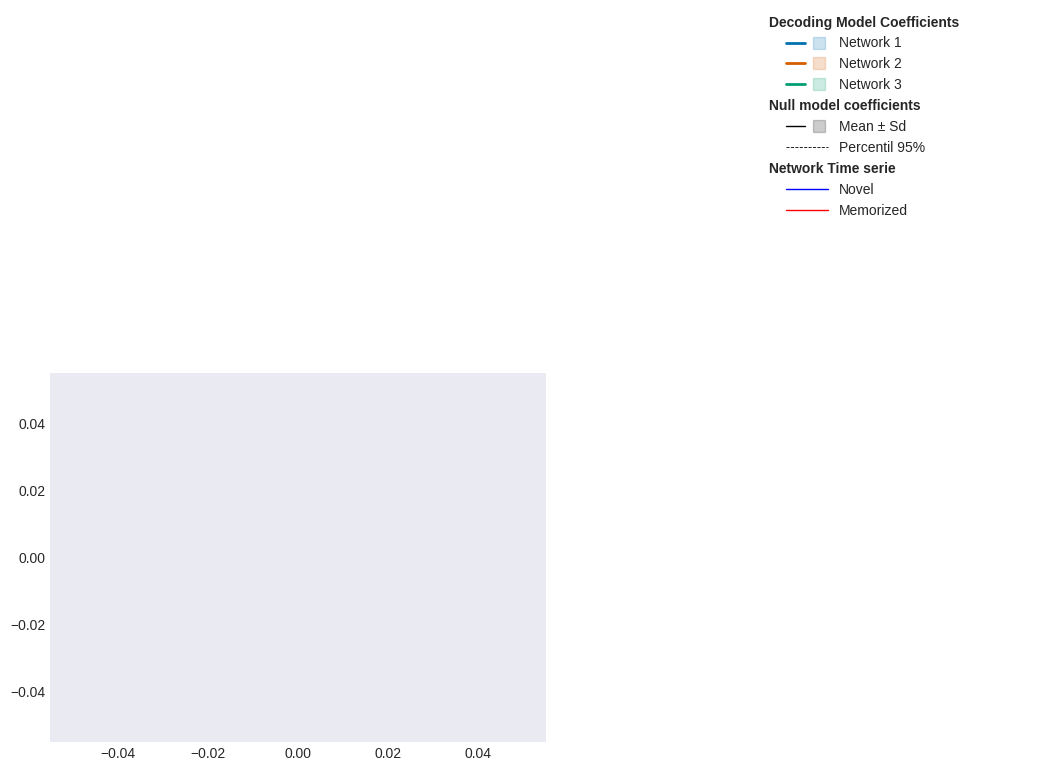

In [17]:
from matplotlib.legend_handler import HandlerTuple
from src.config import color_event
fig, ax= plt.subplots()

leg_el = []
leg_label =[]
for pc in [0, 1, 2]: 
    line = Line2D([], [], color=col_pc[pc], lw=2)
    square = Line2D([], [], marker='s', color=col_pc[pc], alpha = 0.2,linestyle='None', markersize=8)

    leg_el.append((line, square))
    leg_label.append(f'Network {pc+1}')

# null model legend 
lines_null = [(Line2D([], [], alpha = 1, linewidth=1, color = 'black'), 
              Line2D([], [],  linestyle='None', marker='s', alpha = 0.2, color = 'black', markersize=8)),
              Line2D([], [], alpha = 1,ls='--', linewidth=0.6, color = 'black')]

label_null = ['Mean ± Sd', 'Percentil 95%']

# exp conditions
lines_condi = [Line2D([], [], alpha = 1, linewidth=1, color = color_event[0]), 
               Line2D([], [], alpha = 1, linewidth=1, color = color_event[1])]
label_condi=['Novel', 'Memorized']


# title and separators:
lines_tot = [Line2D([], [], linestyle='None')] + leg_el + [Line2D([], [], linestyle='None')] + lines_null + [Line2D([], [], linestyle='None')] + lines_condi 
label_tot = ['Decoding Model Coefficients'] + leg_label + ['Null model coefficients'] +label_null+ ['Network Time serie'] + label_condi
             

leg = ax.legend(lines_tot,label_tot,
    handler_map={tuple: HandlerTuple(ndivide=None)},
    handlelength=3, 
    bbox_to_anchor=((2, 2)), ncol=1
)


for h, txt in zip(leg.legend_handles, leg.get_texts()):
    if not txt.get_text() in label_null+ label_condi+leg_label:
        h.set_visible(False)
        txt.set_weight('bold')
        txt.set_x(-70)

ax.plot()
plt.show()

## SVC RBF

In [29]:
# SVC rbf cropped
band = 'broadband'
method_pca = 'mean'
data_aug_method = 'mean'
PC_use = 1
model_name = 'SVC_rbf'

acc= []
acc_sh = []
id_time = np.linspace(0, len(time_epoch), 10, dtype = int)
for i in range(len(id_time)-1) : 
    time = time_epoch[id_time[i]:id_time[i+1]]
    #time = time_tfr[id_time[i]:id_time[i+1]]
    try : 
        df_final = pd.read_csv(OUT_PATH + f'/Decoding_shuffled_trials/{band}/fullmodel/{method_pca}_{data_aug_method}_{PC_use}_{model_name}full_crp{0}_{id_time[i+1]}_.csv') 
        result = cleandfdecodingTS(df_final, len(time))
        acc.append(result['acc'])
        acc_sh.append(result['acc_sh'])
    except : 
        continue

/Volumes/barbara/Desktop/MIB_iEEG/utils.py:2229: RuntimeWarning: Mean of empty slice.
  return_dict['weight_mean'] = weight.mean(0)
/opt/anaconda3/envs/MEGEEG/lib/python3.12/site-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/opt/anaconda3/envs/MEGEEG/lib/python3.12/site-packages/numpy/_core/_methods.py:218: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/MEGEEG/lib/python3.12/site-packages/numpy/_core/_methods.py:175: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/anaconda3/envs/MEGEEG/lib/python3.12/site-packages/numpy/_core/_methods.py:207: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/Volumes/barbara/Desktop/MIB_iEEG/utils.py:2229: RuntimeWarning: Mean of empty slice.
  return_dict['weight_mean'] = weight.mean(0)
/opt/anaconda3/envs/MEGEEG/l

In [39]:
cum_acc= []
cum_acc_sh = []
id_time = np.linspace(0, len(time_epoch), 10, dtype = int)
for i in range(len(id_time)-1) : 
    time = time_tfr[0:id_time[i+1]]
    try : 
        df_final = pd.read_csv(OUT_PATH + f'/Decoding_shuffled_trials/{band}/fullmodel/{method_pca}_{data_aug_method}_{PC_use}_{model_name}full_crp{id_time[i]}_{id_time[i+1]}_.csv') 
        result = cleandfdecodingTS(df_final, len(time))
        cum_acc.append(result['acc'])
        cum_acc_sh.append(result['acc_sh'])
    except : 
        continue

/Volumes/barbara/Desktop/MIB_iEEG/utils.py:2229: RuntimeWarning: Mean of empty slice.
  return_dict['weight_mean'] = weight.mean(0)
/opt/anaconda3/envs/MEGEEG/lib/python3.12/site-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/opt/anaconda3/envs/MEGEEG/lib/python3.12/site-packages/numpy/_core/_methods.py:218: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/MEGEEG/lib/python3.12/site-packages/numpy/_core/_methods.py:175: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/anaconda3/envs/MEGEEG/lib/python3.12/site-packages/numpy/_core/_methods.py:207: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/Volumes/barbara/Desktop/MIB_iEEG/utils.py:2229: RuntimeWarning: Mean of empty slice.
  return_dict['weight_mean'] = weight.mean(0)
/opt/anaconda3/envs/MEGEEG/l

Text(0.5, 1.0, 'PC2 time serie')

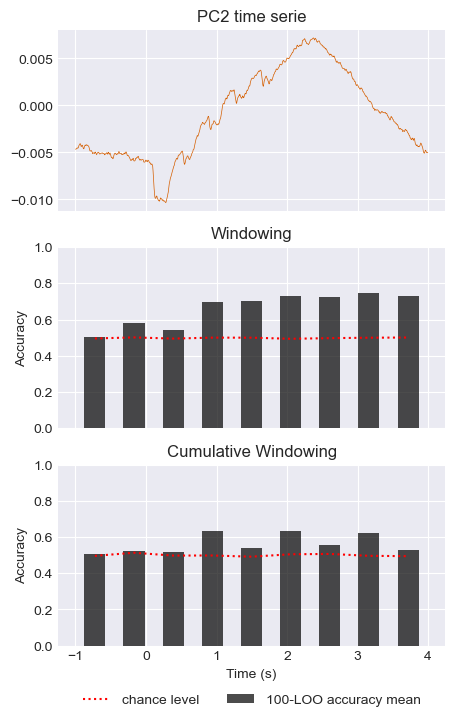

In [109]:
fig, ax = plt.subplots(3, 1, sharex=True, figsize=(5, 8))
t_edges = [time_epoch[t] for t in [int((id_time[i] + id_time[i+1])/2) for i in range(len(id_time)-1)]]

ax[1].bar(
    t_edges,
    acc,
    width=0.3,
    align='center',
    color='black',
    alpha=0.7,
    label='100-LOO accuracy mean'
)

ax[2].bar(
    t_edges,
    cum_acc,
    width=0.3,
    align='center',
    color='black',
    alpha=0.7,
    label='100-LOO accuracy mean'
)


transform = pd.read_csv(OUT_PATH +  f'/grpPCA/supsubj_bb_{method_pca}/grp_Xtrans_PCA5.csv')
compo_lab = 'compo' + str(PC_use+1)
time_serie_df = transform.query('freq == @band and compo == @compo_lab')
for col in ['Unnamed: 0', 'freq' , 'compo', 'subj', 'expl_var'] :
    if col in time_serie_df.columns :
        time_serie_df = time_serie_df.drop(columns = col)
time_serie = time_serie_df.values

col_pc = {0:"#0072B2", 1:"#D55E00", 2:"#009E73", 4:"#009E73"}
ax[0].plot(time_epoch,time_serie[0, :int(time_serie.shape[1]/2)], ls='-', c=col_pc[PC_use], label='PC landscape', linewidth = 0.5)

ax[2].plot(t_edges, cum_acc_sh, ls=':', c='r', label='chance level')

ax[1].plot(t_edges, acc_sh, ls=':', c='r', label='chance level')
   
for a in ax : 
    a.grid()

ax[1].set_ylim([0, 1])
ax[2].set_ylim([0, 1])

ax[2].legend(bbox_to_anchor=(0.5, -0.3), loc='center', ncol=3)
ax[2].set_xlabel('Time (s)')
ax[1].set_ylabel('Accuracy')
ax[2].set_ylabel('Accuracy')
ax[1].set_title('Windowing')
ax[2].set_title('Cumulative Windowing')
ax[0].set_title('PC2 time serie')

## Compare models

In [10]:
PC_use = 0
band = 'high_gamma'
method_pca = 'concat'
time = time_tfr
from utils import cleandfdecodingTS


In [11]:
all_rows = []

for data_aug_method in ['mean', 'duplicat']:

    res_dict = {'model': [], 'all': [], 'all_sh': [], 'BS': []}

    for model_name in ['LR', 'SVC_linear', 'SVC_rbf', 'RandomForest']:
        try : 
            df_final = pd.read_csv(
                OUT_PATH + f'/Decoding_shuffled_trials/{band}/fullmodel/'
                f'{method_pca}_{data_aug_method}_{PC_use}_{model_name}full.csv'
            )
            result = cleandfdecodingTS(df_final, len(time))

            acc_all = result['acc']
            acc_sh = result['acc_sh']
            res_dict['all'].append(acc_all)
            res_dict['all_sh'].append(acc_sh)
        except : 
            print('ALL', model_name, data_aug_method)


        try:
            df_final = pd.read_csv(
                OUT_PATH + f'/Decoding_shuffled_trials/{band}/fullmodel/'
                f'{method_pca}_{data_aug_method}_{PC_use}_{model_name}full_crp0_18_.csv'
            )
            result = cleandfdecodingTS(df_final, len(time[:18]))
            acc_bs = result['acc']
            res_dict['BS'].append(acc_bs)
        except:
            print('BS', model_name, data_aug_method)

        res_dict['model'].append(model_name.replace('_', ' '))
    
        

    df_tmp = pd.DataFrame(res_dict)
    df_tmp['augmentation'] = data_aug_method
    all_rows.append(df_tmp)

df = pd.concat(all_rows, ignore_index=True)


/Volumes/barbara/Desktop/MIB_iEEG/utils.py:2226: RuntimeWarning: Mean of empty slice.
  return_dict['weight_mean'] = weight.mean(0)
/opt/anaconda3/envs/MEGEEG/lib/python3.12/site-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/opt/anaconda3/envs/MEGEEG/lib/python3.12/site-packages/numpy/_core/_methods.py:218: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/MEGEEG/lib/python3.12/site-packages/numpy/_core/_methods.py:175: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/anaconda3/envs/MEGEEG/lib/python3.12/site-packages/numpy/_core/_methods.py:207: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/Volumes/barbara/Desktop/MIB_iEEG/utils.py:2226: RuntimeWarning: Mean of empty slice.
  return_dict['weight_mean'] = weight.mean(0)
/opt/anaconda3/envs/MEGEEG/l

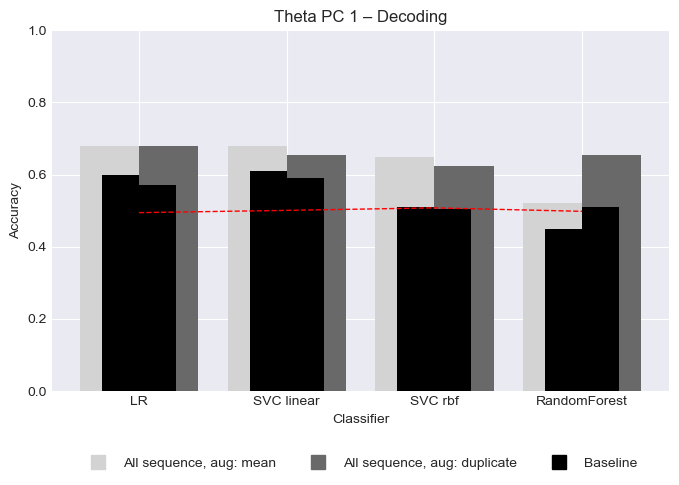

In [12]:
fig, ax = plt.subplots(figsize=(7,5))

sns.barplot(
    data=df,
    x='model',
    y='all',
    hue='augmentation',
    ax=ax, alpha = 1, palette = {'mean': 'lightgrey', 'duplicat':'dimgrey'}
)

sns.barplot(
    data=df,
    x='model',
    y='BS',
    hue='augmentation',
    ax=ax, alpha = 1, width=0.5, palette={'mean': 'k', 'duplicat':'k'}
)

# Chance level (average across augmentation methods)
chance = df.groupby('model')['all_sh'].mean().values
ax.plot(np.arange(len(chance)), chance, ls='--', color='r', linewidth=1, label='Chance Level')

ax.set_ylim(0, 1)
ax.set_ylabel('Accuracy')
ax.set_xlabel('Classifier')
ax.set_title(f'{band.capitalize().replace('_', ' ')} PC {PC_use + 1} – Decoding')
ax.grid(True)


legend_lines = [Line2D([0], [0], linestyle='None', marker='s', markersize=10, alpha = 1,
           markerfacecolor='lightgrey', markeredgecolor='lightgrey', label='All sequence, aug: mean'),
           Line2D([0], [0], linestyle='None', marker='s', markersize=10, alpha = 1,
           markerfacecolor='dimgrey', markeredgecolor='dimgrey', label='All sequence, aug: duplicate'), 
    
           Line2D([0], [0], linestyle='None', marker='s', markersize=10, alpha = 1,
           markerfacecolor='k', markeredgecolor='k', label='Baseline')]

ax.legend(handles= legend_lines, bbox_to_anchor=(0.5, -0.2), loc='center', ncol=3)

plt.tight_layout()


In [54]:
band = 'delta'
pc_use =0

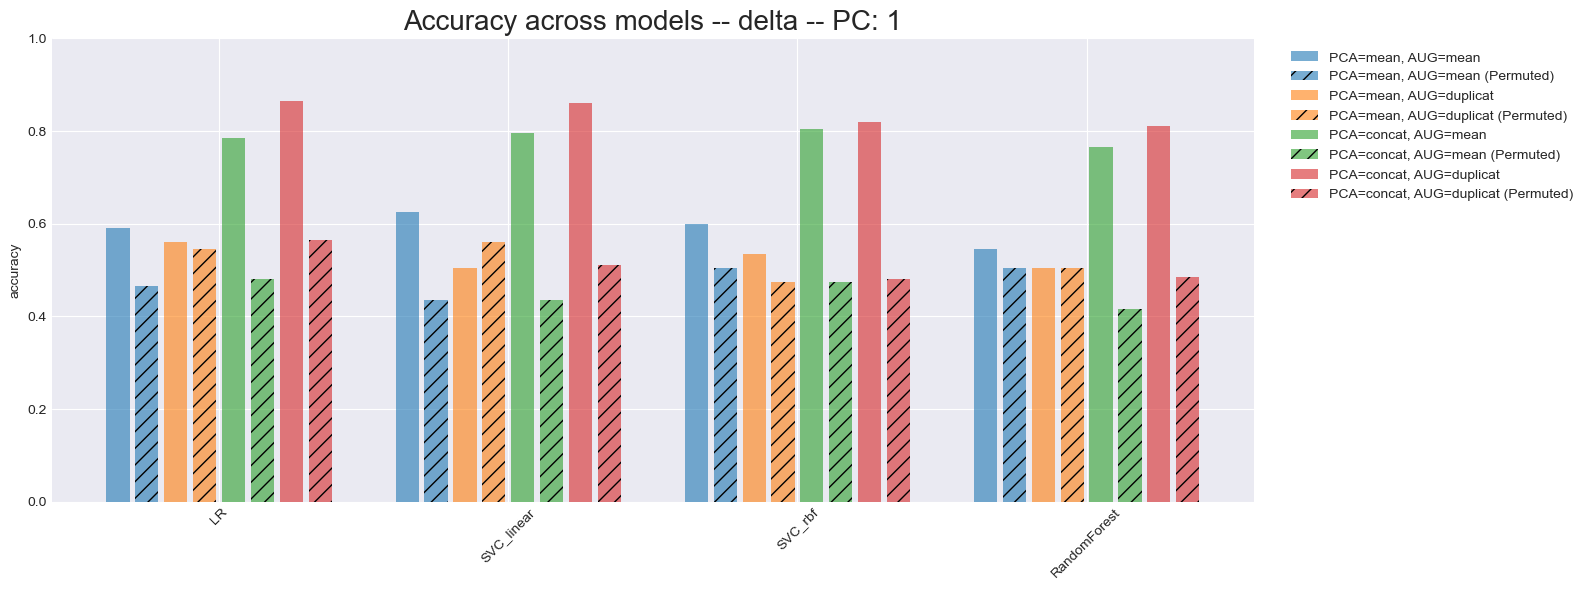

In [55]:
score = 'acc'
CompareModelsGGPlot(score, band, pc_use, decoding_folder=OUT_PATH + '/Decoding') 

# Temporal generalization


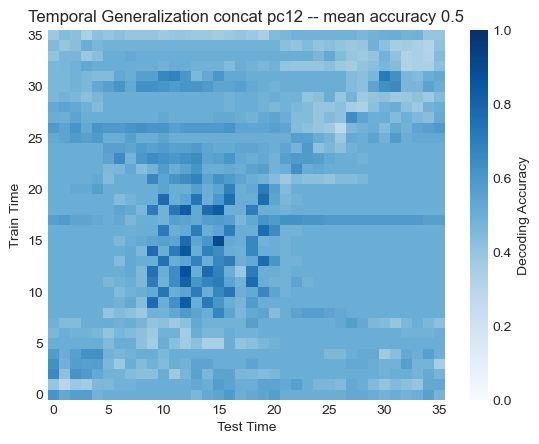

In [ ]:
from utils import TemporalGeneralizationRaw # to use PC1 and PC2

TemporalGeneralizationRaw('broadband', 'mean', subj_included, 
                          save=False,PC_use=[0, 1],
                          method_pca='concat', undersampling=True, 
                          data_path = OUT_PATH + '/Data_shortWOBS')  


# METHOD 1 -- PCA + Decoding 

LR, temporal LR, Temporal generalization using LR \
PC1 and PC2 all band + broad band


In [5]:
from utils import LR, TemporalLR, TemporalGeneralization, TemporalLRRaw, TemporalGeneralizationRaw

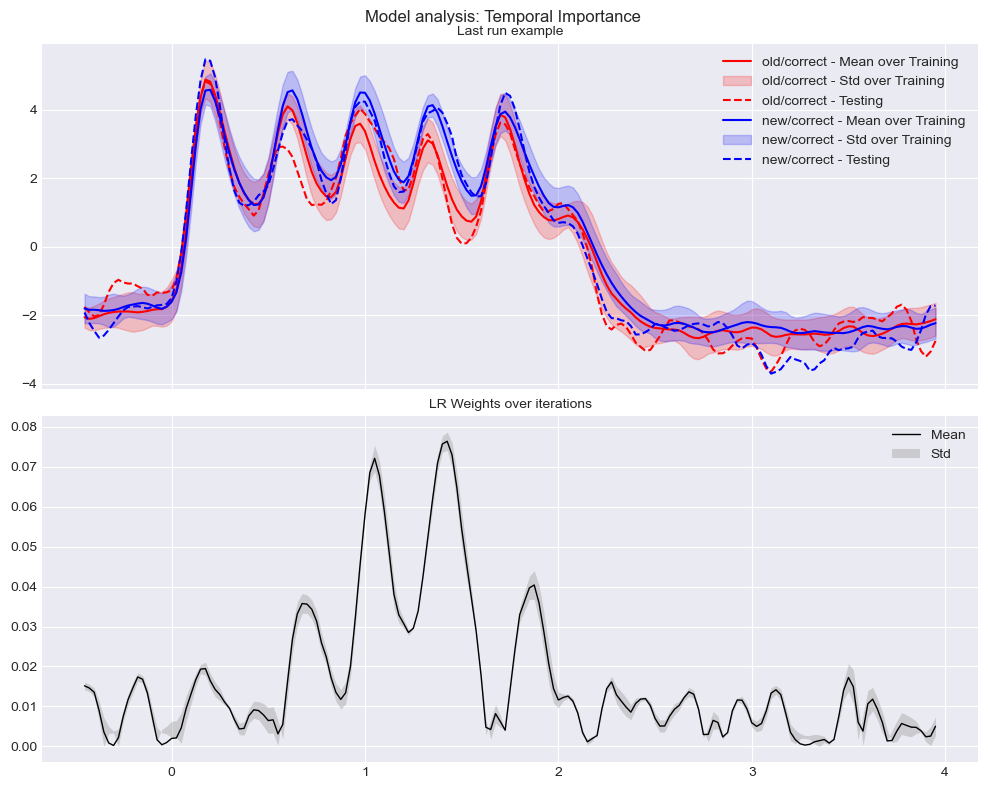

In [15]:
band = 'broadband'
method_pca = 'mean'
data_aug_method = 'mean'
pc_use =0
itera = 3
iter_perm =0

sumsum = LR(band=band, 
   method_pca=method_pca, 
   data_aug_method=data_aug_method,
   subj_included=subj_included, 
   iteration=itera, 
   perm=False,
   iter_perm=iter_perm,  
   PC_use=pc_use, 
   save=False, 
   data_path=tfr_path)

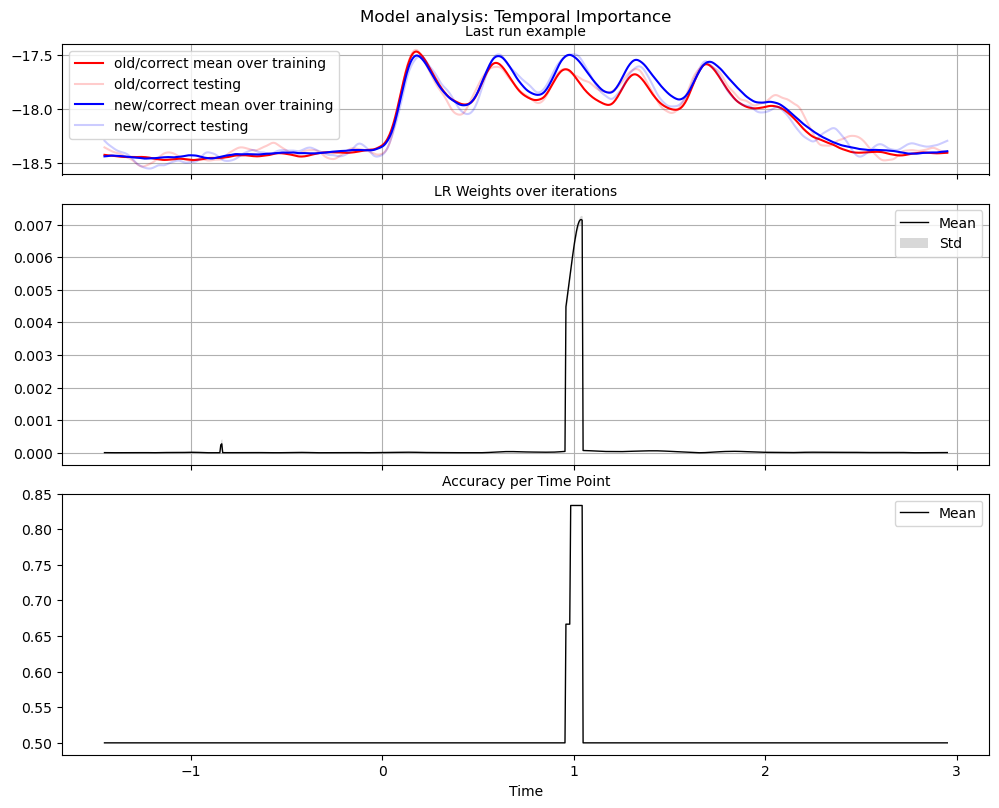

In [9]:
summary = TemporalLR(band=band, 
   method_pca=method_pca, 
   data_aug_method=data_aug_method,
   subj_included=subj_included, 
   iteration=itera, 
   PC_use=pc_use, 
   save=False, 
   data_path=tfr_path)

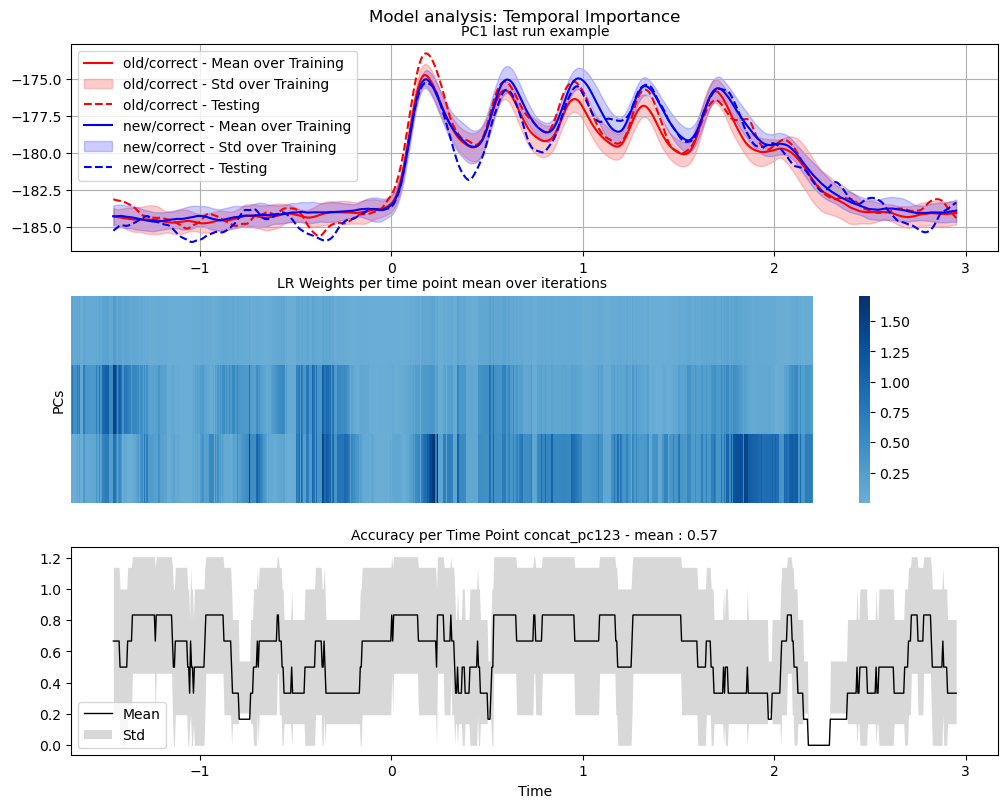

In [13]:
summary = TemporalLRRaw(band=band, 
                        method_pca=method_pca, 
                        data_aug_method=data_aug_method,
                        subj_included=subj_included, 
                        iteration=itera, 
                        PC_use=[0, 1, 2], 
                        save=False, 
                        data_path=tfr_path)

# RAW and PC 1 and 2

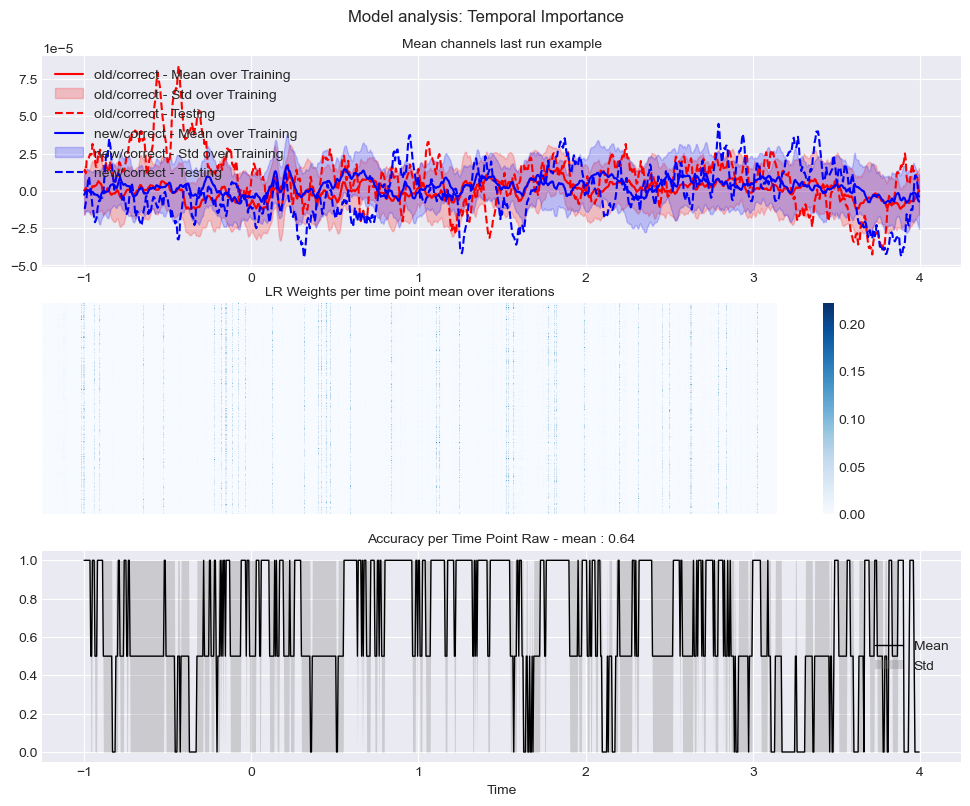

,0
band,broadband
method_data_augm,duplicat
nb_iter,1
gg_accuracy,0.64
acc_mean,"[[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.5,..."
acc_std,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.5,..."


In [3]:
from utils import TemporalLRRaw

TemporalLRRaw(band='broadband', 
                data_aug_method='duplicat',
                subj_included=subj_included, 
                iteration=1, 
                PC_use=False, 
                method_pca=False, 
                save=False, 
                data_path=tfr_path)


In [24]:
res = pd.read_csv('/Volumes/barbara/Desktop/MIB_iEEG/outs/Decoding_shuffled_trials/broadband/broadband_Raw_mean_TpointSummary.csv').set_index('Unnamed: 0')

In [30]:
res

,0
Unnamed: 0,
band,broadband
method_data_augm,mean
nb_iter,100
gg_accuracy,0.58
acc_mean,"[array([0.48 , 0.48 , 0.54 , 0.555, 0.585, 0.5..."
acc_std,"[array([0.49959984, 0.49959984, 0.49839743, 0...."
weights,"[array([[ 6.03587555e-05, 4.46864800e-05, 1...."


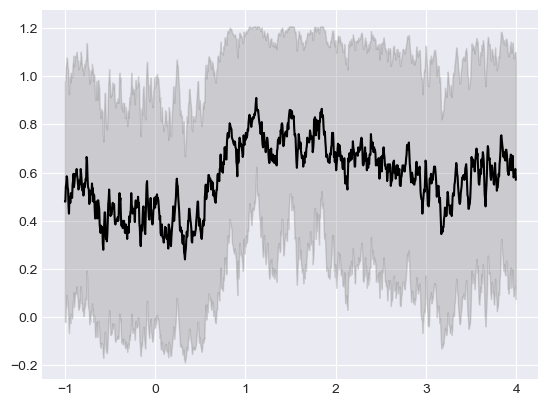

In [ ]:
acc = res.loc['acc_mean','0'].replace('[', '').replace(']', '').replace("\n", "").replace("'", "").replace(" ", "").replace('array(', '').replace(')', '').split(',')
acc= np.array([float(t) for t in acc])

acc_std = res.loc['acc_std','0'].replace('[', '').replace(']', '').replace("\n", "").replace("'", "").replace(" ", "").replace('array(', '').replace(')', '').split(',')
acc_std= np.array([float(t) for t in acc_std])


plt.plot(time_epoch, acc, c='k')
plt.fill_between(time_epoch,  acc - acc_std, acc+acc_std, alpha = 0.3, color='grey')
plt.grid()

In [ ]:
from utils import TemporalGeneralizationRaw
TemporalGeneralizationRaw(band=band, 
                        data_aug_method=data_aug_method, 
                        subj_included=subj_included, 
                        PC_use=False, 
                        method_pca=False, 
                        save=False, 
                        data_path=OUT_PATH +'/Data_shortWOBS')

# METHOD 2

In [ ]:
X_train, y_train, X_test, y_test, subj_track_train = DataTransformationM2(freq=band, PC_use=0, subj_included=subj_included, method_pca='concat')

# Shuffle samples
X_train, y_train, subj_train = shuffle(X_train, y_train, subj_track_train, random_state =0)

# Scale
scaler = TimeSeriesScalerMinMax()
X_train = scaler.fit_transform(X_train)[:,:,0] # normalize amplitude per trials
X_test = scaler.transform(X_test)[:,:,0] # use the same scaler for testing set


/users/barbara/miniforge3/envs/mne_iEEG/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/users/barbara/miniforge3/envs/mne_iEEG/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/users/barbara/miniforge3/envs/mne_iEEG/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


/tmp/ipykernel_5614/1860695868.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


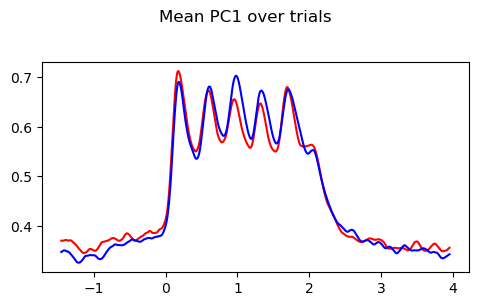

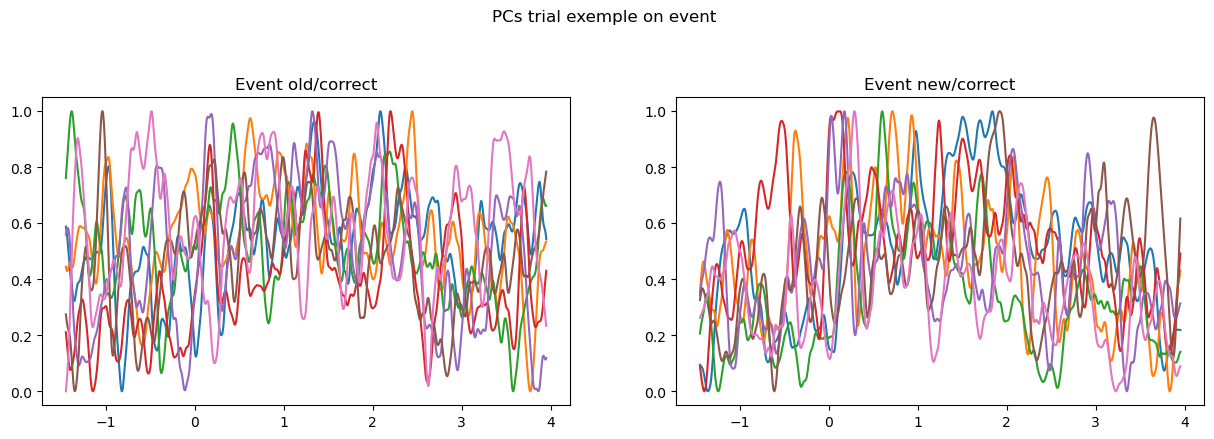

In [ ]:
CheckTrials(X_train, y_train)

### Training Testing

In [ ]:
# LR CV that optimize the lr coef
modelLR = LogisticRegressionCV(cv=5, random_state = 0, n_jobs=1, max_iter=1000, scoring='accuracy', solver='newton-cg')
modelLR.fit(X_train, y_train)
y_pred = modelLR.predict(X_test)

print('Testing f1 : ', f1_score(y_pred, y_test))
print('Testing accuracy : ', accuracy_score(y_pred, y_test)) 

/users/barbara/miniforge3/envs/mne_iEEG/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Testing f1 :  0.6582278481012658
Testing accuracy :  0.55


### Model analysis

Text(87.59722222222221, 0.5, 'Accuracy drop')

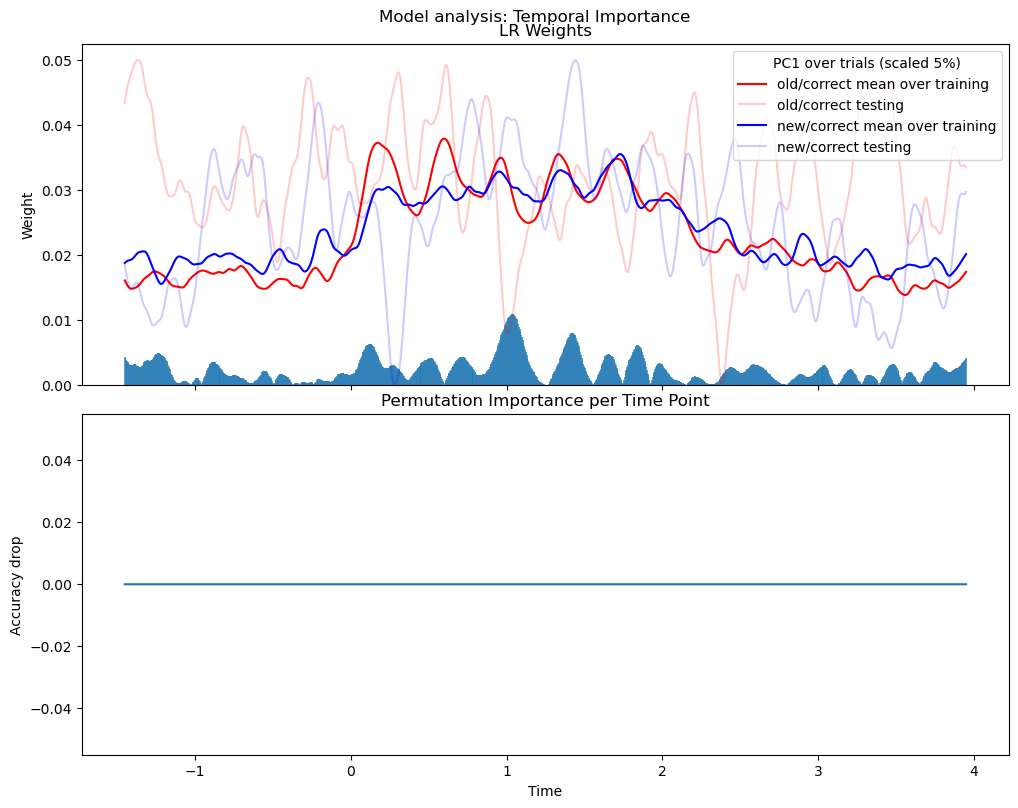

In [ ]:
# check model
fig, axs = plt.subplots(2, 1, figsize = (10, 8), sharex=True)
fig.suptitle('Model analysis: Temporal Importance')
fig.tight_layout()

weights_clf = modelLR.coef_.ravel()
axs[0].bar(time, abs(weights_clf), alpha = 0.7, width=0.01)

for ev_i, ev in enumerate([id_ev1, id_ev2]) : 
    axs[0].plot(time, X_train[ev, :].mean(0) *0.05, label = f'{event[ev_i]} mean over training', color = color_ev[ev_i]) 
    axs[0].plot(time, X_test[ev_i, :] *0.05, label = f'{event[ev_i]} testing', color = color_ev[ev_i], alpha = 0.2)

axs[0].set_title("LR Weights")
axs[0].set_ylabel("Weight")
axs[0].legend(title = 'PC1 over trials (scaled 5%)')

result = permutation_importance(modelLR, X_test, y_test, n_repeats=20, random_state=0)
axs[1].plot(time, result.importances_mean)
axs[1].set_title("Permutation Importance per Time Point")
axs[1].set_xlabel("Time")
axs[1].set_ylabel("Accuracy drop")

# OLD

## Temporal decoding -- On raw TFR --- EVERY BAND

In [ ]:
df_Componants_mean = pd.read_csv(OUT_PATH + f'/grpPCA/supsubj_bb_mean/grp_Compo_PCA{nb_compo}.csv').drop(columns = 'Unnamed: 0')  # TODO change 
weights_mean = df_Componants_mean.drop(columns = ['freq', 'compo']).values # TODO change 

In [ ]:
all_trials= DataAugmentation(save=False, freq='broadband') # TODO change

In [ ]:
# apply mean PCA
all_trials_transformed = np.zeros((all_trials.shape[0], all_trials.shape[1], weights_mean.shape[0], all_trials.shape[3]))

for ev_id in range(all_trials.shape[1]) : 
    for trial_id in range(all_trials.shape[0]) : 
        all_trials_transformed[trial_id, ev_id, :, :] =  weights_mean @ all_trials[trial_id, ev_id,:, :]

all_trials_transformed.shape

(24, 2, 3, 1100)

/users/barbara/miniforge3/envs/mne_iEEG/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/users/barbara/miniforge3/envs/mne_iEEG/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/users/barbara/miniforge3/envs/mne_iEEG/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


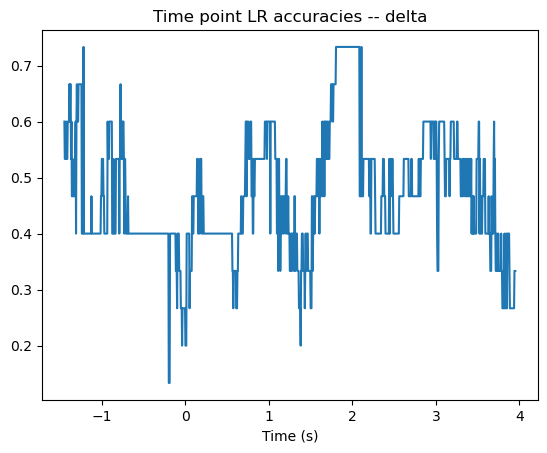

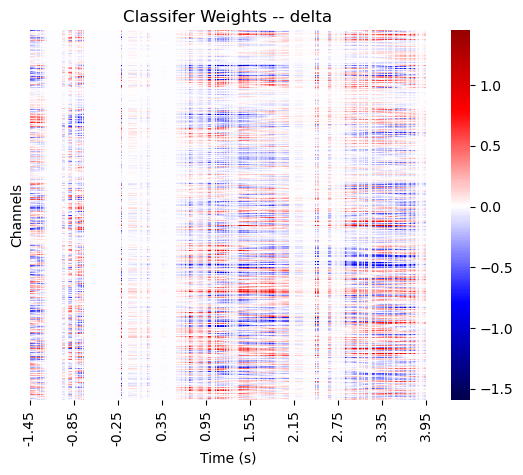

/users/barbara/miniforge3/envs/mne_iEEG/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/users/barbara/miniforge3/envs/mne_iEEG/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/users/barbara/miniforge3/envs/mne_iEEG/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


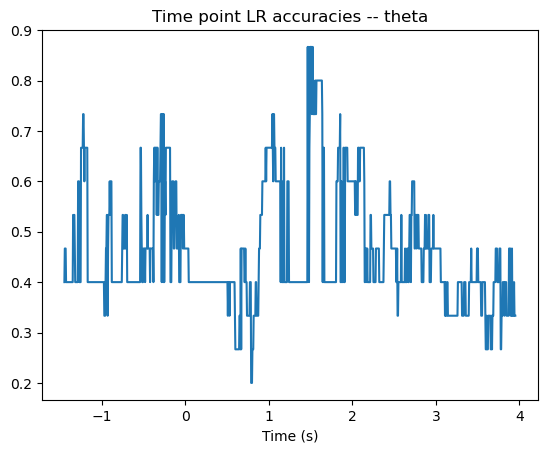

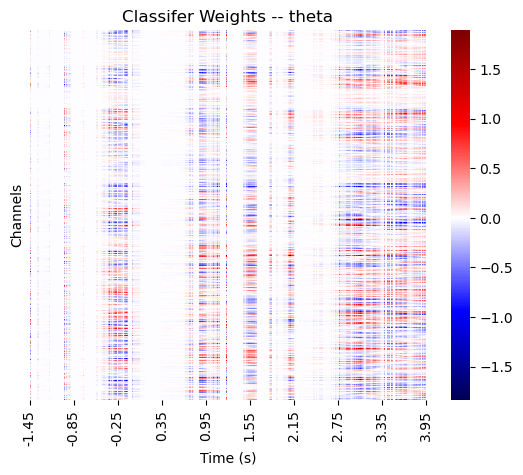

/users/barbara/miniforge3/envs/mne_iEEG/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/users/barbara/miniforge3/envs/mne_iEEG/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/users/barbara/miniforge3/envs/mne_iEEG/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


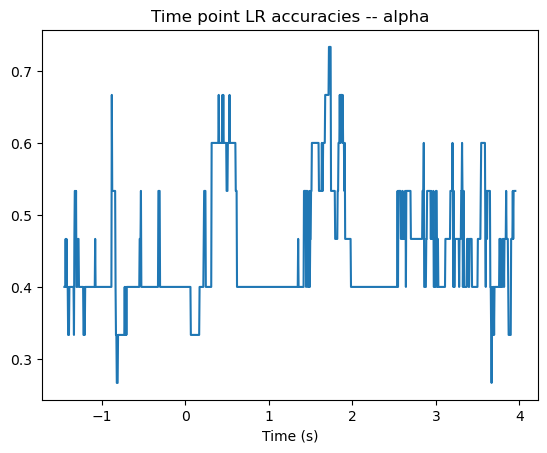

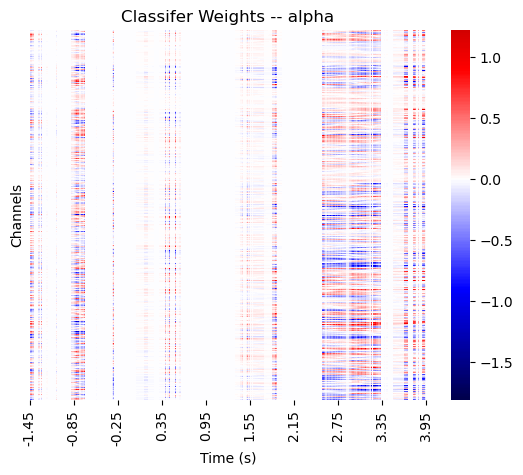

/users/barbara/miniforge3/envs/mne_iEEG/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/users/barbara/miniforge3/envs/mne_iEEG/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/users/barbara/miniforge3/envs/mne_iEEG/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


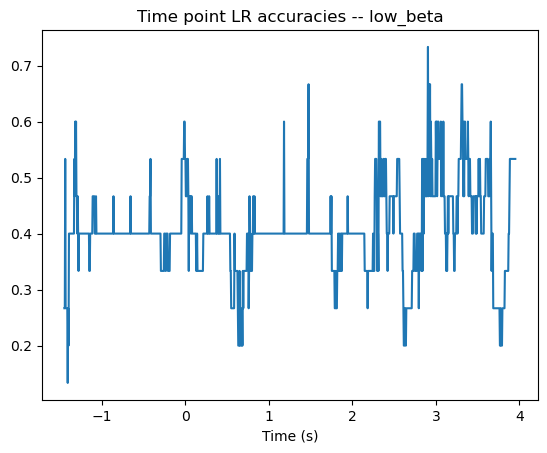

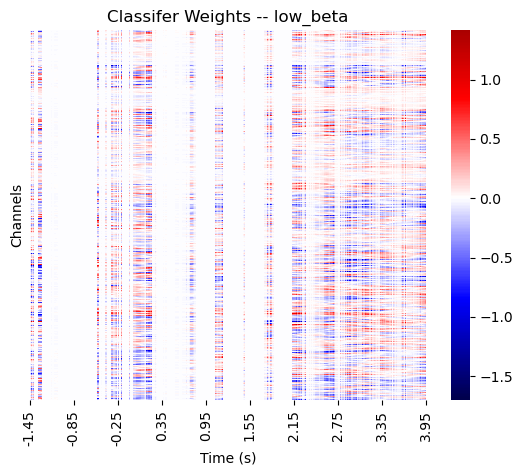

/users/barbara/miniforge3/envs/mne_iEEG/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/users/barbara/miniforge3/envs/mne_iEEG/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/users/barbara/miniforge3/envs/mne_iEEG/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


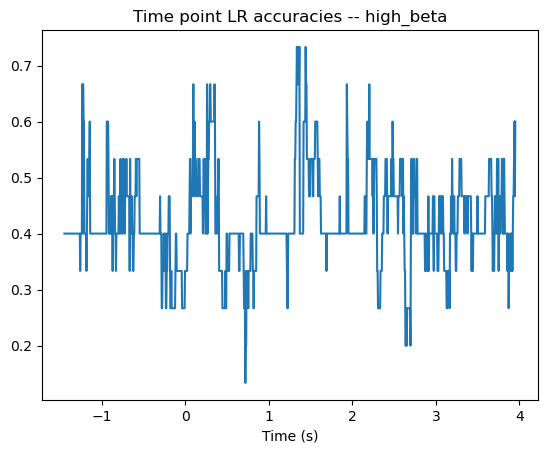

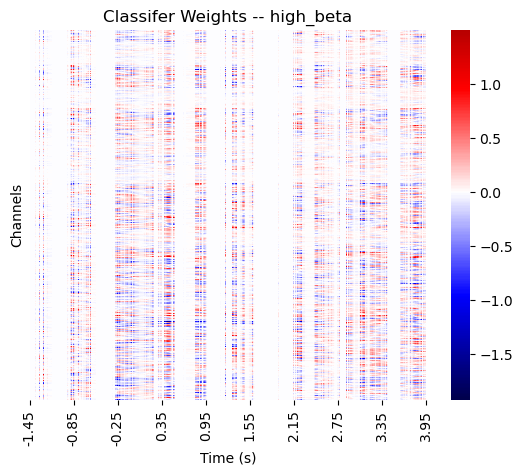

/users/barbara/miniforge3/envs/mne_iEEG/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/users/barbara/miniforge3/envs/mne_iEEG/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/users/barbara/miniforge3/envs/mne_iEEG/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


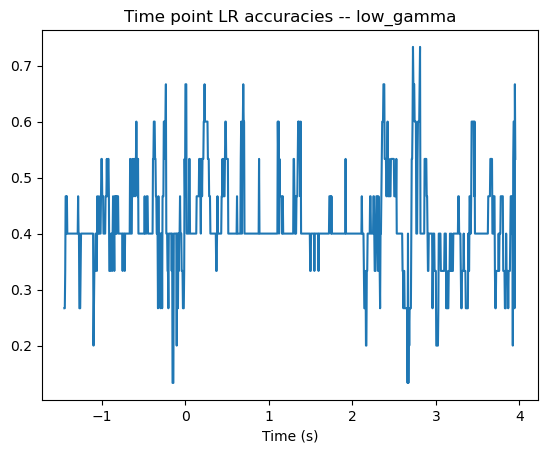

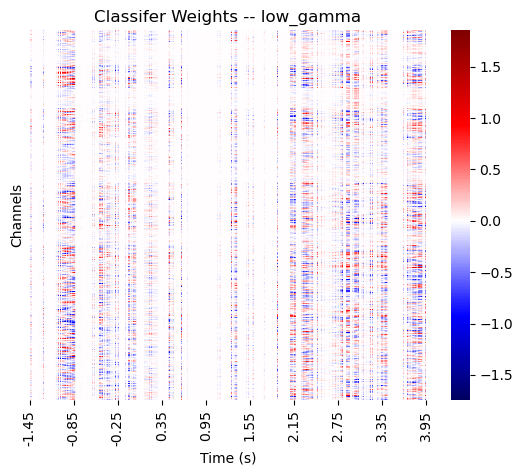

/users/barbara/miniforge3/envs/mne_iEEG/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/users/barbara/miniforge3/envs/mne_iEEG/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/users/barbara/miniforge3/envs/mne_iEEG/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


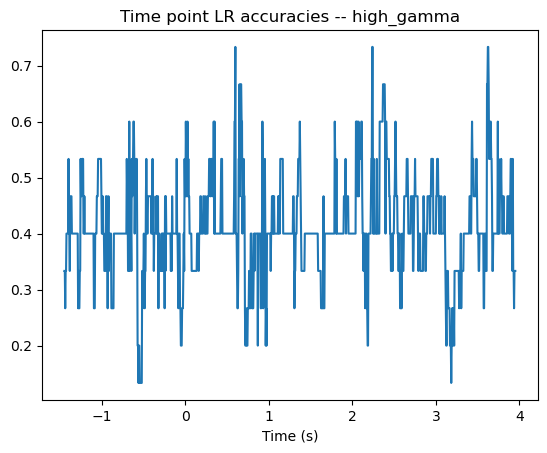

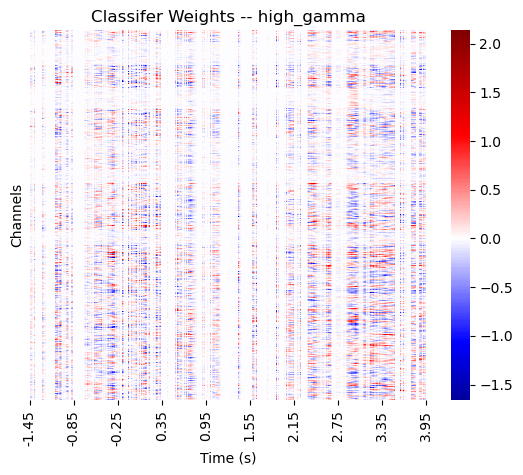

In [ ]:
for band in FREQ_BAND : 
    weights_mean = df_Componants_mean.query("freq == @band").drop(columns = ['freq', 'compo']).values
    weights_concat = df_Componants_concat.query("freq == @band").drop(columns = ['freq', 'compo']).values
    all_trials = DataAugmentation(save=False, freq=band)
    X = np.concatenate([all_trials[:, 0, :,:], all_trials[:, 1, :,:]], axis = 0)
    y= [0]*all_trials_transformed.shape[0] + [1]*all_trials_transformed.shape[0]

    file = f'{OUT_PATH}/Decoding/True_trials.p'
    with open(file, "rb") as f:
        True_trials = pickle.load(f)
    weight_balanced = True_trials.sum(axis = 2)/30
    weight_balanced =  np.concatenate([weight_balanced[:, 0], weight_balanced[:, 1]], axis = 0) # concat event 0 and 1

    X, y, weight_balanced = shuffle(X, y, weight_balanced, random_state =0) # shuffle samples

    # split 
    X_train = X[:int(len(y)*0.7), :, :]
    X_test= X[int(len(y)*0.7):, :, :]
    y_train = y[:int(len(y)*0.7)]
    y_test= y[int(len(y)*0.7):]
    weight_balanced_train = weight_balanced[:int(len(y)*0.7)]
    weight_balanced_test = weight_balanced[int(len(y)*0.7):]

    scaler = TimeSeriesScalerMinMax()
    X_train = scaler.fit_transform(X_train) # normalize amplitude per trials
    X_test = scaler.transform(X_test)

    accuracies = []
    weights = []

    for t_point in range(X_train.shape[2]) :
        clf = LogisticRegressionCV(cv=5, random_state = 0, n_jobs=1, max_iter=1000, scoring='accuracy').fit(X_train[:, :,t_point], y_train)
        accuracies.append(clf.score(X_test[:,:,t_point], y_test))
        weights.append(clf.coef_.ravel())


    plt.tight_layout()
    plt.plot(time, accuracies)
    plt.xlabel('Time (s)')
    plt.title(f'Time point LR accuracies -- {band}')
    plt.show()
  
    plt_df = pd.DataFrame(np.vstack(weights))
    plt_df['time'] = time
    sns.heatmap(plt_df.set_index('time').T, cmap= 'seismic', center=0, yticklabels=[], xticklabels=50)
    plt.xticks(ticks=np.linspace(0, len(time)-1, 10),
            labels=[f"{t:.2f}" for t in np.linspace(time[0], time[-1], 10)])
    plt.xlabel('Time (s)')
    plt.ylabel('Channels')
    plt.title(f'Classifer Weights -- {band}')
    plt.show()

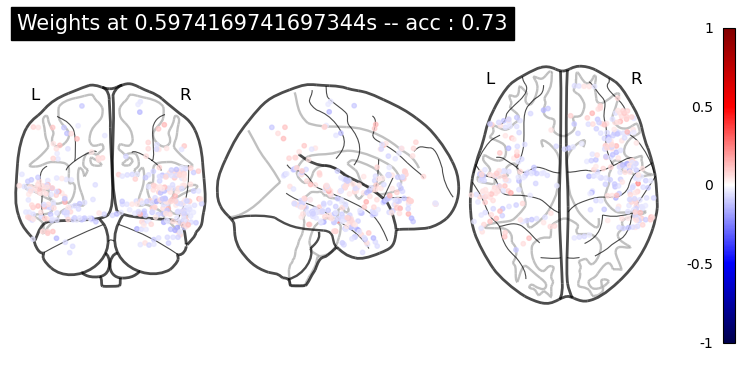

In [ ]:
# get the time point of max accuracy
ind_max = accuracies.index(max(accuracies))

coord, _, _ = GetInfo(subj_included)
coord_array = np.array(coord)

thr = weights[ind_max].mean() + weights[ind_max].std()
index_thr = np.where(abs(weights[ind_max]) > thr)
node_max = max(abs(weights[ind_max]))
fig1 = plotting.plot_markers(node_coords = coord_array[index_thr],  node_size=10, node_values=weights[ind_max][index_thr], node_cmap='seismic', title=f'Weights at {time[ind_max]}s -- acc : {np.round(accuracies[ind_max], 2)}',display_mode='ortho', node_vmax=1, node_vmin=-1)


In [ ]:
fig, ax = plt.subplots(1, len(FREQ_BAND), figsize= (5*len(FREQ_BAND), 5))
for i_b, band in enumerate(FREQ_BAND) : 
    weights_mean = df_Componants_mean.query("freq == @band").drop(columns = ['freq', 'compo']).values
    weights_concat = df_Componants_concat.query("freq == @band").drop(columns = ['freq', 'compo']).values
    all_trials = DataAugmentation(save=False, freq=band)

    X = np.concatenate([all_trials[:, 0, :,:], all_trials[:, 1, :,:]], axis = 0)
    y= [0]*all_trials_transformed.shape[0] + [1]*all_trials_transformed.shape[0]

    file = f'{OUT_PATH}/Decoding/True_trials.p'
    with open(file, "rb") as f:
        True_trials = pickle.load(f)
    weight_balanced = True_trials.sum(axis = 2)/30
    weight_balanced =  np.concatenate([weight_balanced[:, 0], weight_balanced[:, 1]], axis = 0) # concat event 0 and 1

    X, y, weight_balanced = shuffle(X, y, weight_balanced, random_state =0) # shuffle samples

    scaler = TimeSeriesScalerMinMax()
    X_train = scaler.fit_transform(X) # normalize amplitude per trials

    weights = []
    accuracies = np.zeros((X.shape[2], X.shape[2]))
    for t_point_train in range(X.shape[2]) :
        clf = LogisticRegressionCV(cv=5, random_state = 0, n_jobs=1, max_iter=1000, scoring='accuracy').fit(X[:, :,t_point_train], y)

        for t_point_test in range(X.shape[2]) :
            accuracies[t_point_train, t_point_test] = clf.score(X[:,:,t_point_test], y)

        weights.append(clf.coef_.ravel())

    sns.heatmap(accuracies, xticklabels=50, yticklabels=50, vmax=1, vmin=0.5, ax=ax[i_b])
    ax[i_b].set_xticks(ticks=np.linspace(0, len(time)-1, 10),labels=[f"{t:.2f}" for t in np.linspace(time[0], time[-1], 10)])
    ax[i_b].set_yticks(ticks=np.linspace(0, len(time)-1, 10),labels=[f"{t:.2f}" for t in np.linspace(time[0], time[-1], 10)])
    ax[i_b].set_xlabel('Time point: train')
    ax[i_b].set_ylabel('Time point: test')
    ax[i_b].set_title(f'Logistic Regression Timepoint Accuracy -- {band}')
    plt.show()

/users/barbara/miniforge3/envs/mne_iEEG/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/users/barbara/miniforge3/envs/mne_iEEG/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


concat mean


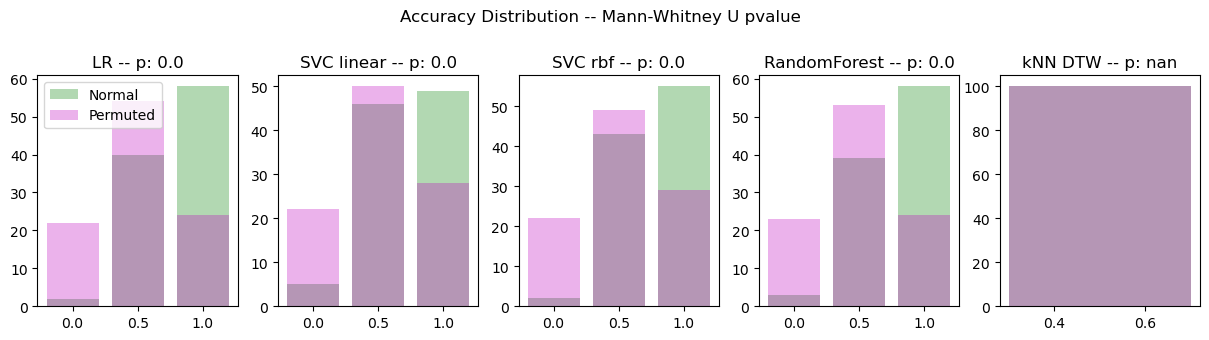

In [63]:

score='accuracy'
#for method_pca in ['mean', 'concat'] : 
#    for data_aug_method in ['mean', 'duplicat'] :
df_perm = pd.read_csv(OUT_PATH + f'/Decoding/{band}/{method_pca}_{data_aug_method}_permuted_{pc_use}_CompareModels.csv').rename(columns = {'Unnamed: 0' : 'scores'}).set_index('scores')
df = pd.read_csv(OUT_PATH + f'/Decoding/{band}/{method_pca}_{data_aug_method}_{pc_use}_CompareModels.csv').rename(columns = {'Unnamed: 0' : 'scores'}).set_index('scores')

df.loc[score, :] = df.loc[score, :].apply(lambda x : clean_df(x))
df_perm.loc[score, :] = df_perm.loc[score, :].apply(lambda x : clean_df(x))

print(method_pca, data_aug_method)
PlotScoreDistrib(score, df, df_perm)


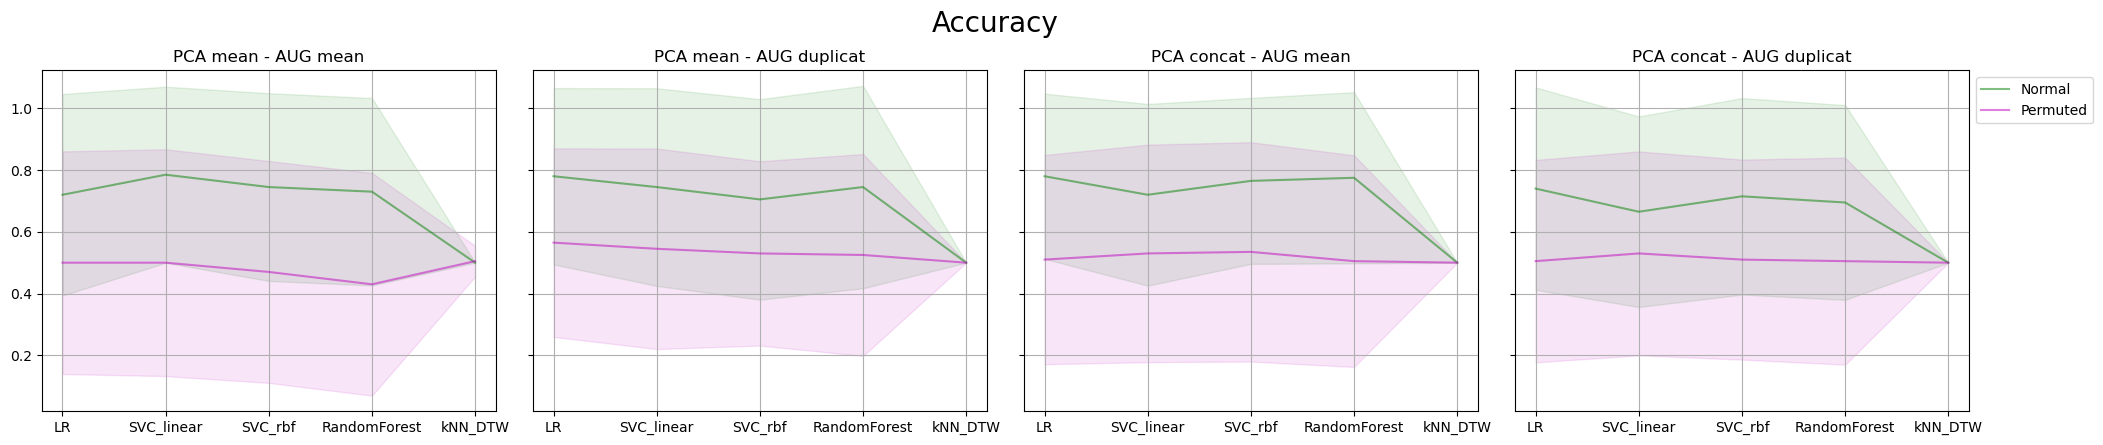

In [64]:
i=0
fig, ax = plt.subplots(1,4,  figsize= (4*5, 4), sharex=True, sharey=True)
fig.tight_layout()
score = 'accuracy'
fig.suptitle(score.capitalize(), size=20, y=1.1)
for method_pca in ['mean', 'concat'] : 
    for data_aug_method in ['mean', 'duplicat'] :
        df_perm = pd.read_csv(OUT_PATH + f'/Decoding/{band}/{method_pca}_{data_aug_method}_permuted_{pc_use}_CompareModels.csv').rename(columns = {'Unnamed: 0' : 'scores'}).set_index('scores')
        df = pd.read_csv(OUT_PATH + f'/Decoding/{band}/{method_pca}_{data_aug_method}_{pc_use}_CompareModels.csv').rename(columns = {'Unnamed: 0' : 'scores'}).set_index('scores')

        df.loc[score, :] = df.loc[score, :].apply(lambda x : clean_df(x))
        df_perm.loc[score, :] = df_perm.loc[score, :].apply(lambda x : clean_df(x))

        mean_acc =[]
        mean_acc_p =[]
        std_acc = []
        std_acc_p =[]

        for model in df.columns :
            mean_acc.append(np.mean(df.loc[score, model]))
            mean_acc_p.append(np.mean(df_perm.loc[score, model]))

            std_acc.append(np.std(df.loc[score, model]))
            std_acc_p.append(np.std(df_perm.loc[score, model]))

        mean_acc = np.array(mean_acc)
        std_acc = np.array(std_acc)
        mean_acc_p = np.array(mean_acc_p)
        std_acc_p =np.array(std_acc_p)

        ax[i].plot(df.columns, mean_acc, 'g', alpha = 0.5, label = 'Normal')
        ax[i].fill_between(df.columns, mean_acc - std_acc, mean_acc+std_acc, color = 'g', alpha = 0.1)
        
        ax[i].plot(df.columns, mean_acc_p, 'm', alpha = 0.5, label = 'Permuted')
        ax[i].fill_between(df.columns, mean_acc_p-std_acc_p, mean_acc_p+std_acc_p, color='m', alpha = 0.1)
        ax[i].set_title('PCA '+ method_pca + ' - AUG ' + data_aug_method)
        ax[i].grid()
        i+=1
ax[i-1].legend(loc='best', bbox_to_anchor = (1, 1))


In [ ]:
from utils import PermLR_null, PermLR_distrib, PermLR_Final
from scipy.stats import mannwhitneyu

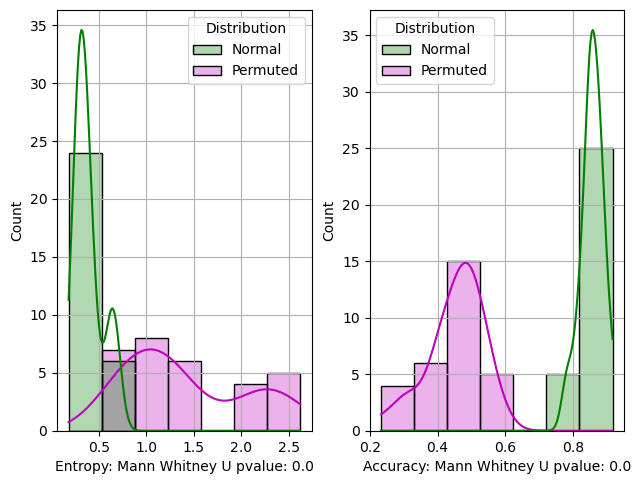

In [ ]:
band = 'high_gamma'
method_pca = 'concat'
data_aug_method = 'mean'

perm_file_distrib = pd.read_csv(OUT_PATH + f'/Decoding/stats/PermDistrub_{band}_{method_pca}_{data_aug_method}.csv').rename(columns = {'0' : 0}).set_index('Unnamed: 0')
fig, ax = plt.subplots(1, 2)
fig.tight_layout()
to_plot = pd.DataFrame()
for l in ['acc','entropy'] :
    perm_file_distrib.loc[l, :] = perm_file_distrib.loc[l, :].apply(lambda x: clean_df(x))
    perm_file_distrib.loc[l + '_p', :] = perm_file_distrib.loc[l + '_p', :].apply(lambda x: clean_df(x))
    to_plot.loc[:, l] = perm_file_distrib.loc[l, :].values[0] + perm_file_distrib.loc[l + '_p', :].values[0]

    to_plot.loc[:, 'Distribution'] = ['Normal']*30 +['Permuted']*30

p_acc = mannwhitneyu(to_plot.query("Distribution == 'Normal'")['acc'], to_plot.query("Distribution == 'Permuted'")['acc'])[1]
p_entropy = mannwhitneyu(to_plot.query("Distribution == 'Normal'")['entropy'], to_plot.query("Distribution == 'Permuted'")['entropy'])[1]


sns.histplot(to_plot, x='entropy', hue='Distribution',ax=ax[0], kde=True, palette={'Normal': 'g', 'Permuted':'m'}, alpha = 0.3)
ax[0].set_xlabel(f'Entropy: Mann Whitney U pvalue: {np.round(p_entropy, 4)}')
ax[0].grid()

sns.histplot(to_plot, x='acc', hue='Distribution',ax=ax[1], kde=True,  palette={'Normal': 'g', 'Permuted':'m'}, alpha = 0.3)
ax[1].set_xlabel(f'Accuracy: Mann Whitney U pvalue: {np.round(p_acc, 4)}')
ax[1].grid()

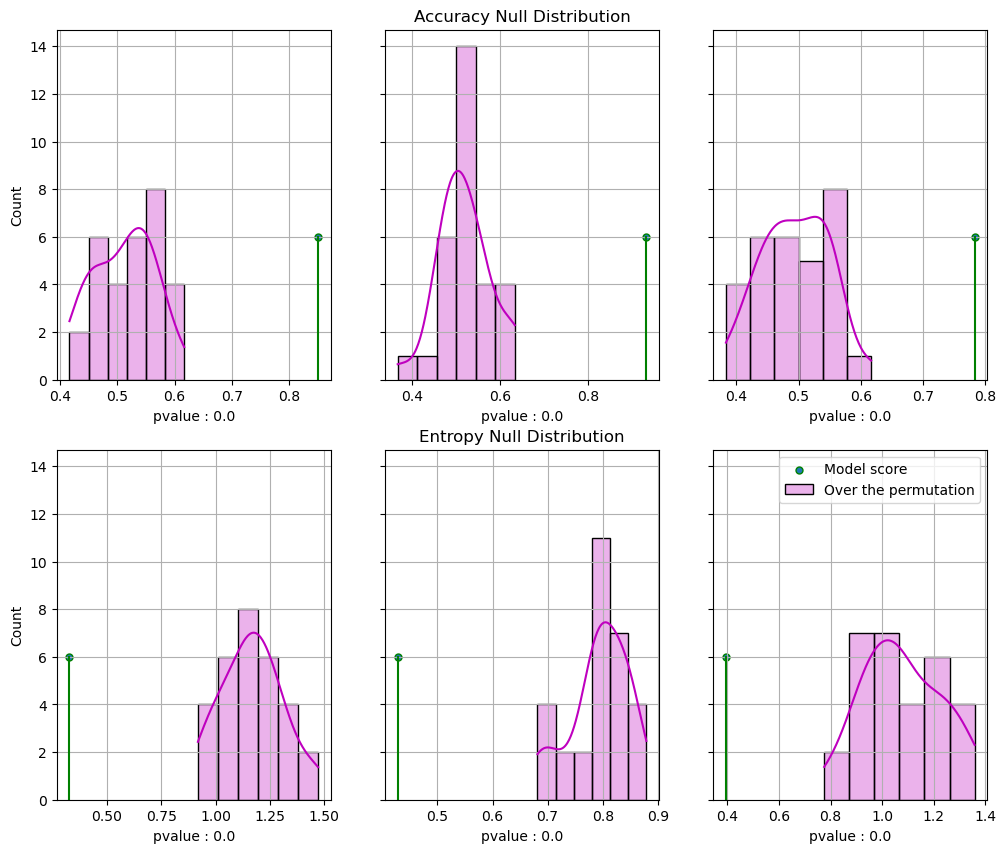

In [ ]:
band = 'high_gamma'
method_pca = 'concat'
data_aug_method = 'mean'

perm_file_null = pd.read_csv(OUT_PATH + f'/Decoding/stats/PermNull_{band}_{method_pca}_{data_aug_method}_pc1.csv').rename(columns = {'0' : 0}).set_index('Unnamed: 0').rename(columns ={'1' : 1, '2':2})

for l in ['acc_p','entropy_p'] :
    perm_file_null.loc[l, :] = perm_file_null.loc[l, :].apply(lambda x: clean_df(x))

fig, ax = plt.subplots(2, 3, sharey=True, figsize= (12, 10))
to_plot = pd.DataFrame()

for s in range(3) : 
    for i, l in enumerate(['acc_p','entropy_p']) :
        to_plot.loc[:, l] = perm_file_null.loc[l, s]
        sns.histplot(to_plot, x=l, ax=ax[i][s], color='m', alpha = 0.3, kde=True,  label = 'Over the permutation')

        drawhlinex = [float(perm_file_null.loc[l.replace('_p', ''), s]), float(perm_file_null.loc[l.replace('_p', ''), s])]
        drawhliney = [0, 6]
        ax[i][s].plot(drawhlinex, drawhliney, 'g')
        ax[i][s].scatter(drawhlinex[i], 6, edgecolors='g', marker='.', s=100, label = 'Model score')

        acc_p = np.array(perm_file_null.loc[l, s]) 
        acc = float(perm_file_null.loc[l.replace('_p', ''),s])
        if 'acc' in l :
            mask = [acc_p >= acc][0]
            title = 'Accuracy'
        else : 
            mask = [acc_p <= acc][0]
            title = 'Entropy'
        pval = np.round(len(acc_p[mask])/len(acc_p), 7)

        ax[i][s].set_xlabel(f'pvalue : {pval}')
        ax[i][1].set_title(f'{title} Null Distribution')
        ax[i][s].grid()
        
ax[i][s].legend()
        

In [9]:
# sol0 -- 

df = pd.read_csv(OUT_PATH  + '/Decoding/high_gamma/high_gamma_concat_mean_summary.csv').set_index('Unnamed: 0')

df.loc['for_pvalues_acc', :] = df.loc['for_pvalues_acc', :].apply(lambda x : clean_df(x))
df.loc['for_pvalues_ll', :] = df.loc['for_pvalues_ll', :].apply(lambda x : clean_df(x))
df.loc['current_acc', :] = df.loc['current_acc', :].apply(lambda x : clean_df(x))
df.loc['current_ll', :] = df.loc['current_ll', :].apply(lambda x : clean_df(x))
num_acc = []
num_entropy = []
to_plot_acc =pd.DataFrame()
to_plot_entropy =pd.DataFrame()

iter_perm = 100

for p in range(int(df.loc['nb_iter', '0'])) : 
    acc_p= np.array(df.loc['for_pvalues_acc', :].values[0][int(iter_perm*p):int(iter_perm*(p+1))])
    acc = df.loc['current_acc', :].values[0][p]
    mask = [acc_p >= acc][0]
    num_acc.append(np.round(len(acc_p[mask])/len(acc_p), 5))
    to_plot_acc.loc[:, p] = acc_p

    entropy_p= np.array(df.loc['for_pvalues_ll', :].values[0][int(iter_perm*p):int(iter_perm*(p+1))])
    entropy = df.loc['current_ll', :].values[0][p]
    mask = [entropy_p <= entropy][0]
    num_entropy.append(np.round(len(entropy_p[mask])/len(entropy_p), 5)) # how much over perm_iter
    to_plot_entropy.loc[ :, p] = entropy_p

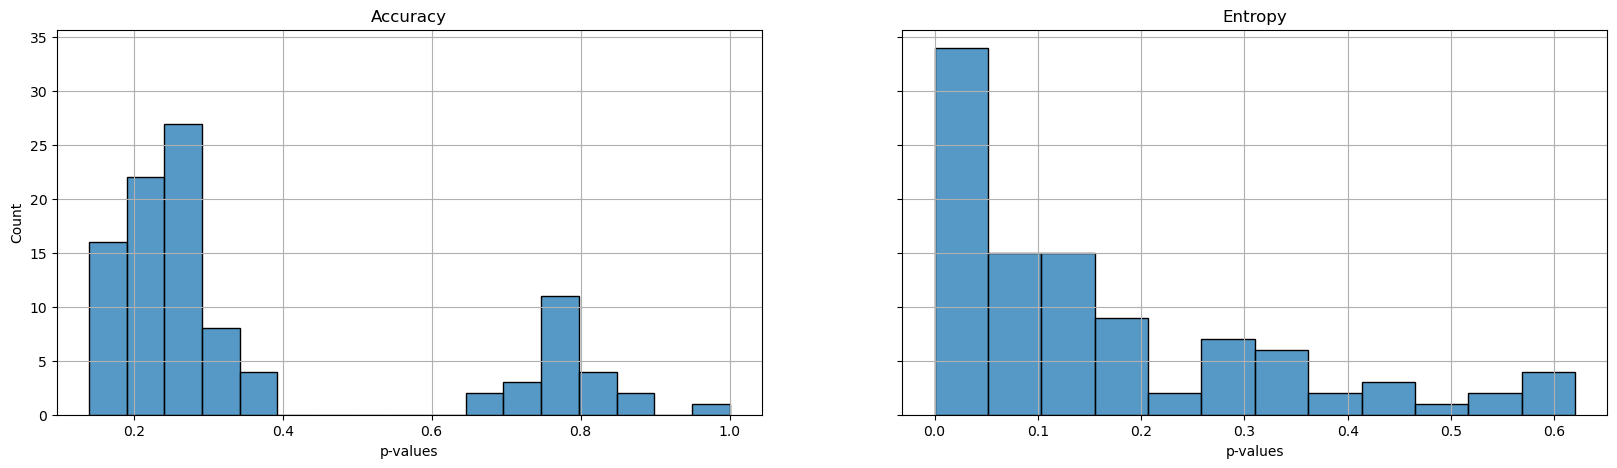

In [10]:
fig, ax = plt.subplots(1, 2, sharey=True, figsize=(20, 5))
sns.histplot(num_acc, ax=ax[0], binwidth=0.05)
ax[0].set_xlabel('p-values')
ax[0].set_title('Accuracy')
ax[0].grid()
sns.histplot(num_entropy, ax=ax[1], binwidth=0.05)
ax[1].set_xlabel('p-values')
ax[1].set_title('Entropy')
ax[1].grid()